<a href="https://colab.research.google.com/github/ochgar/data-science-on-gcp/blob/master/Geographic_Origin_of_Accessions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas pyproj shapely geodatasets matplotlib pandas

In [28]:
from google.colab import files

uploaded = files.upload()

Saving Catalogo_sweet_global_map.csv to Catalogo_sweet_global_map (1).csv


In [29]:
import pandas as pd

df = pd.read_csv("Catalogo_sweet_global_map (1).csv")
df.head()

,Continent,Continent2,Country of origin,Accessions,Color
0,Australia and New Zealand,Oceania,New Zealand,6,#8491B4
1,Australia and New Zealand,Oceania,Australia,2,#8491B4
2,Caribbean,North America,Cuba,182,#7CCCE5
3,Caribbean,North America,Dominican Republic,97,#7CCCE5
4,Caribbean,North America,Jamaica,46,#7CCCE5


# Dataset

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Country":[
        "Peru","Ecuador","United States","Mexico",
        "Spain","Germany","Kenya","South Africa",
        "China","Australia"
    ],
    "Continent":[
        "South America","South America",
        "North America","North America",
        "Europe","Europe",
        "Africa","Africa",
        "Asia","Oceania"
    ],
    "Latitude":[
        -13.5319,-0.1807,
        39.8283,19.4326,
        40.4168,52.5200,
        -1.2921,-25.7479,
        39.9042,-35.2809
    ],
    "Longitude":[
        -71.9675,-78.4678,
        -98.5795,-99.1332,
        -3.7038,13.4050,
        36.8219,28.2293,
        116.4074,149.1300
    ],
    "n_accessions":[
        245,120,85,60,
        45,70,55,95,
        150,110
    ]
})

df.head()

,Country,Continent,Latitude,Longitude,n_accessions
0,Peru,South America,-13.5319,-71.9675,245
1,Ecuador,South America,-0.1807,-78.4678,120
2,United States,North America,39.8283,-98.5795,85
3,Mexico,North America,19.4326,-99.1332,60
4,Spain,Europe,40.4168,-3.7038,45


# Cargar mapa mundial

In [ ]:
import geopandas as gpd

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


# Crear colores por continente

In [ ]:
continent_colors = {
    "South America":"#E64B35",
    "North America":"#4DBBD5",
    "Europe":"#00A087",
    "Africa":"#F39B7F",
    "Asia":"#3C5488",
    "Oceania":"#8491B4"
}

Crear el Bubble Map


Países no encontrados:

[None]


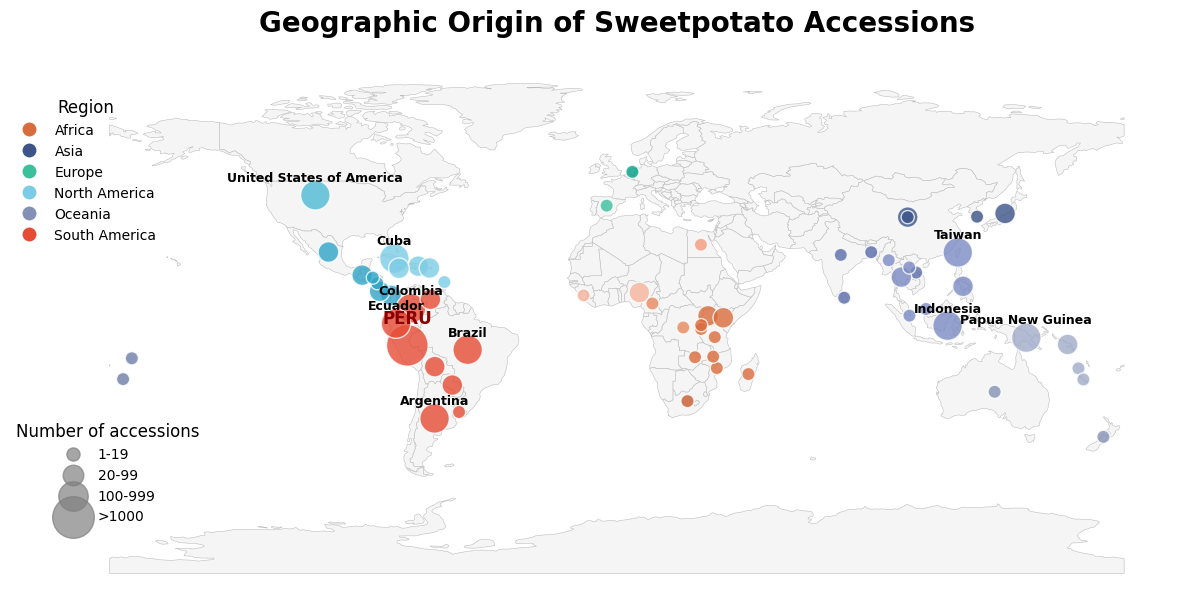

In [54]:
# ==========================================
# LIBRERÍAS
# ==========================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.lines import Line2D
from google.colab import files

# ==========================================
# SUBIR CSV
# ==========================================

#uploaded = files.upload()

#filename = list(uploaded.keys())[0]

#df = pd.read_csv(filename)

#print(df.head())

# ==========================================
# MAPA MUNDIAL
# ==========================================

#world = gpd.read_file(
#    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
#)

# ==========================================
# CENTROIDES DE LOS PAÍSES
# ==========================================

world_proj = world.to_crs("+proj=robin")

centroids = world_proj.copy()
centroids["geometry"] = centroids.centroid

centroids = centroids.to_crs(4326)

country_coords = centroids[["NAME", "geometry"]].copy()

country_coords["Longitude"] = country_coords.geometry.x
country_coords["Latitude"] = country_coords.geometry.y

country_coords = country_coords[
    ["NAME", "Longitude", "Latitude"]
]

# ==========================================
# CORREGIR NOMBRES FRECUENTES
# ==========================================
replacements = {
    "USA": "United States of America",
    "United States": "United States of America",
    "Russia": "Russia",
    "Viet Nam": "Vietnam",
    # Caribe
    "Dominican Republic": "Dominican Rep.",
    "Saint Vincent and the Grenadines": "St. Vin. and Gren.",

    # Asia
    "Korea, Republic of": "South Korea",
    "Hong Kong": "China",
    "Taiwan, Province of China": "Taiwan",

    # Sudeste Asiático
    "Lao People s Democratic Republic": "Laos",
    "Singapore": "Singapore",

    # Oceanía
    "Solomon Islands": "Solomon Is.",
    "Tonga": "Tonga",
    "Samoa": "Samoa",
    "Cook Islands": "Cook Islands",
    "Niue": "Niue",

    # África
    "Congo, The": "Dem. Rep. Congo"
}

df["Country of origin"] = (
    df["Country of origin"]
    .replace(replacements)
)


# ==========================================
# UNIR CON COORDENADAS
# ==========================================

#primero borramos
cols_to_drop = [
    "NAME",
    "Longitude",
    "Latitude",
    "NAME_x",
    "NAME_y",
    "Longitude_x",
    "Longitude_y",
    "Latitude_x",
    "Latitude_y"
]

df = df.drop(
    columns=[c for c in cols_to_drop if c in df.columns],
    errors="ignore"
)

##
df = df.merge(
    country_coords,
    left_on="Country of origin",
    right_on="NAME",
    how="left"
)
##
manual_coords = {
    "Tonga": (-21.1393, -175.2049),
    "Samoa": (-13.7590, -172.1046),
    "Singapore": (1.3521, 103.8198),
    "St. Vin. and Gren.": (13.2528, -61.1971),
    "Cook Islands": (-21.2367, -159.7777),
    "Niue": (-19.0544, -169.8672)
}
for country, (lat, lon) in manual_coords.items():

    mask = (
        (df["Country of origin"] == country)
        & (df["Longitude"].isna())
    )

    df.loc[mask, "Latitude"] = lat
    df.loc[mask, "Longitude"] = lon
# ==========================================
# VERIFICAR PAÍSES NO ENCONTRADOS
# ==========================================

missing = df[df["Longitude"].isna()]

if len(missing) > 0:
    print("\nPaíses no encontrados:\n")
    print(missing["Country of origin"].unique())

# ==========================================
# TAMAÑO DE BURBUJAS
# ==========================================

df["BubbleSize"] = np.sqrt(df["Accessions"]) * 15

# ==========================================
# CLASIFICACIÓN DE TAMAÑOS
# ==========================================

def classify_accessions(n):

    if n >= 1000:
        return ">1000"

    elif n >= 100:
        return "100-999"

    elif n >= 20:
        return "20-99"

    else:
        return "1-19"

df["SizeClass"] = (
    df["Accessions"]
      .apply(classify_accessions)
)

size_map = {
    ">1000": 900,
    "100-999": 450,
    "20-99": 220,
    "1-19": 90
}

df["BubbleSize"] = (
    df["SizeClass"]
      .map(size_map)
)

# ==========================================
# FIGURA
# ==========================================

fig, ax = plt.subplots(
    figsize=(18,10)
)

# Mundo

world.plot(
    ax=ax,
    color="#F5F5F5",
    edgecolor="#BDBDBD",
    linewidth=0.4
)

# ==========================================
# BURBUJAS
# ==========================================

for region in sorted(df["Continent2"].unique()):

    subset = df[
        df["Continent2"] == region
    ]

    ax.scatter(
        subset["Longitude"],
        subset["Latitude"],
        s=subset["BubbleSize"],
        c=subset["Color"],
        alpha=0.80,
        edgecolors="white",
        linewidth=1.0,
        zorder=3
    )

# ==========================================
# ETIQUETAS
# ==========================================

labels = df[
    (df["Accessions"] >= 100) & (df["Country of origin"] != "Peru")
]

for _, row in labels.iterrows():

    ax.text(
        row["Longitude"],
        row["Latitude"] + 5,
        row["Country of origin"],
        fontsize=9,
        fontweight="bold",
        ha="center",
        zorder=4
    )

# Etiqueta especial Perú

peru = df[
    df["Country of origin"] == "Peru"
]

if len(peru) > 0:

    row = peru.iloc[0]

    ax.text(
        row["Longitude"],
        row["Latitude"] + 8,
        "PERU",
        fontsize=12,
        fontweight="bold",
        color="darkred",
        ha="center",
        zorder=5
    )

# ==========================================
# LEYENDA REGIONES
# ==========================================

region_colors = (
    df.groupby("Continent2", as_index=False)
      .first()[["Continent2", "Color"]]
)

region_handles = []

df["Continent2"] = (
    df["Continent2"]
      .astype(str)
      .str.strip()
)

for _, row in region_colors.sort_values("Continent2").iterrows():

    region_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=row["Color"],
            markeredgecolor='none',
            label=row["Continent2"],
            markersize=10
        )
    )

leg1 = ax.legend(
    handles=region_handles,
    title="Region",
    loc="upper left",
    bbox_to_anchor=(-0.05, 0.95),
    frameon=False,
    fontsize=10,
    title_fontsize=12
)

ax.add_artist(leg1)

# ==========================================
# LEYENDA TAMAÑOS
# ==========================================

size_handles = [
    plt.scatter([],[],s=90,color="gray",alpha=0.7,label="1-19"),
    plt.scatter([],[],s=220,color="gray",alpha=0.7,label="20-99"),
    plt.scatter([],[],s=450,color="gray",alpha=0.7,label="100-999"),
    plt.scatter([],[],s=900,color="gray",alpha=0.7,label=">1000")
]

leg2 = ax.legend(
    handles=size_handles,
    title="Number of accessions",
    loc="upper left",
    bbox_to_anchor=(-0.05, 0.35),
    frameon=False,
    fontsize=10,
    title_fontsize=12
)

# ==========================================
# ESTILO
# ==========================================

ax.set_title(
    "Geographic Origin of Sweetpotato Accessions",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_axis_off()

plt.subplots_adjust(left=0.28)

# ==========================================
# GUARDAR
# ==========================================

fig.savefig(
    "world_accessions_map.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "world_accessions_map.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [49]:

# plt.savefig(
#     "world_accessions_map.png",
#     bbox_inches="tight",
#     dpi=600
# )

<Figure size 640x480 with 0 Axes>

In [47]:
from google.colab import files

files.download("world_accessions_map.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>